<a href="https://colab.research.google.com/github/smosharof/Resume.Walkthrough/blob/main/Inventory_Forecast_using_Seasonal_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-1-b299c41e9df8>:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Apparel_Type'].fillna('Other', inplace=True)


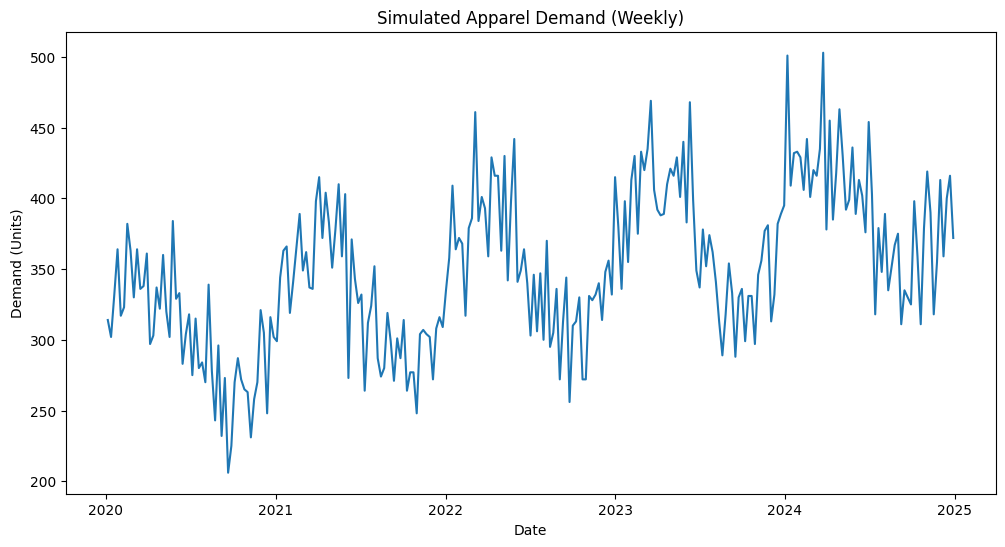

            Demand  Year  WeekOfYear  Month  Holiday_Effect Apparel_Type  \
Date                                                                       
2020-01-05     314  2020           1      1               0       Winter   
2020-01-12     302  2020           2      1               0       Winter   
2020-01-19     332  2020           3      1               0       Winter   
2020-01-26     364  2020           4      1               0       Winter   
2020-02-02     317  2020           5      2               0       Winter   

           Region  
Date               
2020-01-05   West  
2020-01-12  North  
2020-01-19   East  
2020-01-26   West  
2020-02-02  North  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2020-01-05 to 2024-12-29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Demand          261 non-null    int64 
 1   Year            261 non-null    int32 
 2   WeekOfYear      261 non

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate Seasonal Apparel Demand ---
np.random.seed(42)  # For reproducibility

dates = pd.date_range(start='2020-01-01', end='2024-12-31', freq='W')  # Weekly frequency
num_weeks = len(dates)

# Base demand (trend)
trend = np.linspace(100, 200, num_weeks)

# Seasonal pattern (example: summer peak, winter dip)
seasonal = 50 * np.sin(2 * np.pi * np.arange(num_weeks) / 52) + 200

# Random noise
noise = np.random.normal(0, 30, num_weeks)

# Combine components
demand = trend + seasonal + noise
demand = np.maximum(0, demand).astype(int)  # Ensure demand is not negative

# Create DataFrame
df = pd.DataFrame({'Date': dates, 'Demand': demand})
df.set_index('Date', inplace=True)

# Add more realistic features (example - adjust as needed)
df['Year'] = df.index.year
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)
df['Month'] = df.index.month
df['Holiday_Effect'] = 0  # Placeholder - you'd set this based on holiday weeks
df.loc[(df['WeekOfYear'] >= 24) & (df['WeekOfYear'] <= 34), 'Apparel_Type'] = 'Summer'
df.loc[(df['WeekOfYear'] >= 44) | (df['WeekOfYear'] <= 10), 'Apparel_Type'] = 'Winter'
df['Apparel_Type'].fillna('Other', inplace=True)
df['Region'] = np.random.choice(['North', 'South', 'East', 'West'], num_weeks)

# --- Visualize ---
plt.figure(figsize=(12, 6))
plt.plot(df['Demand'])
plt.title('Simulated Apparel Demand (Weekly)')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.show()

print(df.head())
print(df.info())

# --- Now you can use 'df' for your ARIMA modeling ---

<ipython-input-2-d5c7584c2897>:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Apparel_Type'].fillna('Other', inplace=True)


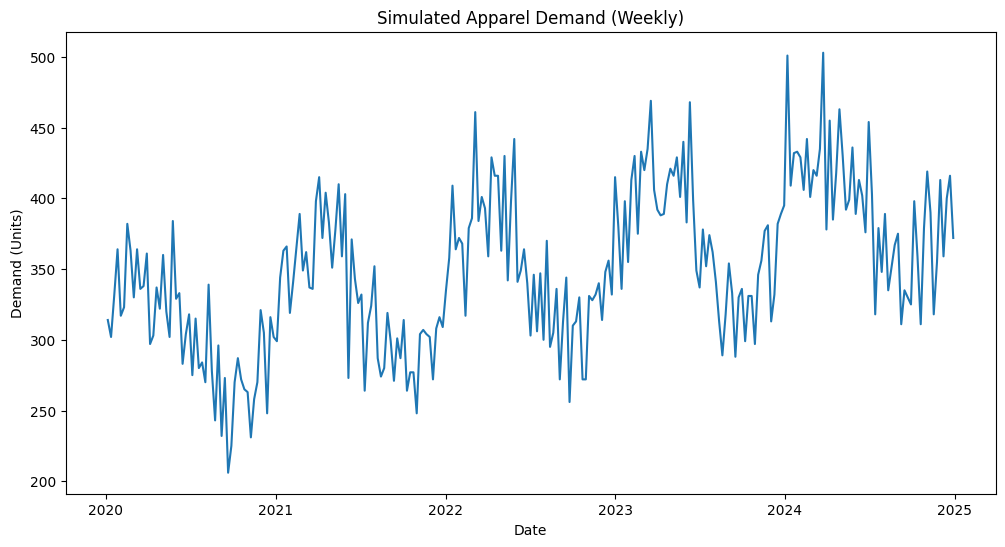

            Demand  Year  WeekOfYear  Month  Holiday_Effect Apparel_Type  \
Date                                                                       
2020-01-05     314  2020           1      1               0       Winter   
2020-01-12     302  2020           2      1               0       Winter   
2020-01-19     332  2020           3      1               0       Winter   
2020-01-26     364  2020           4      1               0       Winter   
2020-02-02     317  2020           5      2               0       Winter   

           Region  
Date               
2020-01-05   West  
2020-01-12  North  
2020-01-19   East  
2020-01-26   West  
2020-02-02  North  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2020-01-05 to 2024-12-29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Demand          261 non-null    int64 
 1   Year            261 non-null    int32 
 2   WeekOfYear      261 non

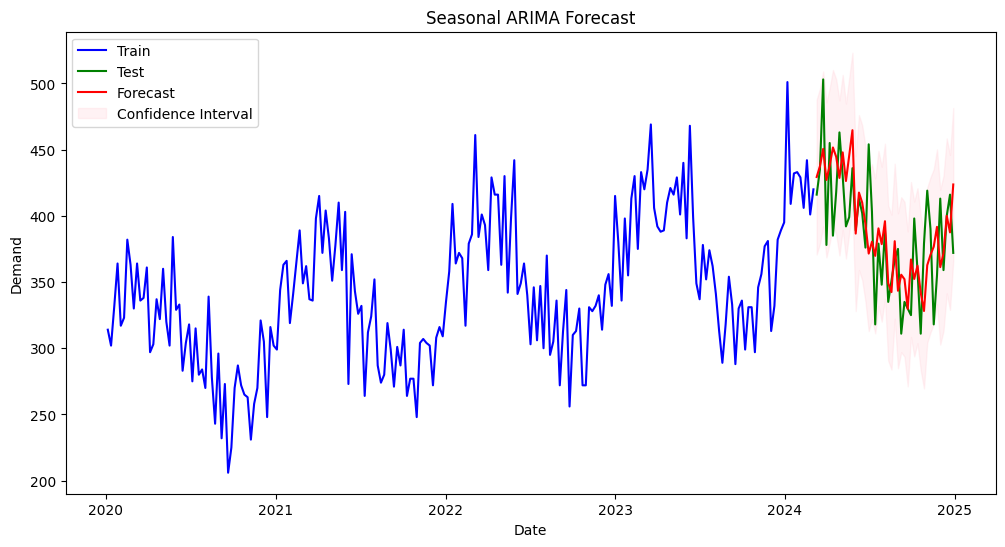

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Load the simulated data (assuming it's already in the df DataFrame as you provided)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate Seasonal Apparel Demand ---
np.random.seed(42)  # For reproducibility

dates = pd.date_range(start='2020-01-01', end='2024-12-31', freq='W')  # Weekly frequency
num_weeks = len(dates)

# Base demand (trend)
trend = np.linspace(100, 200, num_weeks)

# Seasonal pattern (example: summer peak, winter dip)
seasonal = 50 * np.sin(2 * np.pi * np.arange(num_weeks) / 52) + 200

# Random noise
noise = np.random.normal(0, 30, num_weeks)

# Combine components
demand = trend + seasonal + noise
demand = np.maximum(0, demand).astype(int)  # Ensure demand is not negative

# Create DataFrame
df = pd.DataFrame({'Date': dates, 'Demand': demand})
df.set_index('Date', inplace=True)

# Add more realistic features (example - adjust as needed)
df['Year'] = df.index.year
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)
df['Month'] = df.index.month
df['Holiday_Effect'] = 0  # Placeholder - you'd set this based on holiday weeks
df.loc[(df['WeekOfYear'] >= 24) & (df['WeekOfYear'] <= 34), 'Apparel_Type'] = 'Summer'
df.loc[(df['WeekOfYear'] >= 44) | (df['WeekOfYear'] <= 10), 'Apparel_Type'] = 'Winter'
df['Apparel_Type'].fillna('Other', inplace=True)
df['Region'] = np.random.choice(['North', 'South', 'East', 'West'], num_weeks)

# --- Visualize ---
plt.figure(figsize=(12, 6))
plt.plot(df['Demand'])
plt.title('Simulated Apparel Demand (Weekly)')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.show()

print(df.head())
print(df.info())

# 1. Prepare Data for Time Series Analysis
data = df['Demand']  # Extract the time series
data = data.asfreq('W')  # Ensure consistent weekly frequency (important for SARIMAX)
data = data.fillna(data.mean()) # Fill any missing weeks with the mean

# 2. Split Data for Time Series (using TimeSeriesSplit)
# This prevents "future" data from influencing the training set
tscv = TimeSeriesSplit(n_splits=5)  # 5 splits for demonstration; adjust as needed

for train_index, test_index in tscv.split(data):
    train_data = data.iloc[train_index]
    test_data = data.iloc[test_index]

# Use the last split for final training and testing
train_data = data.iloc[train_index]
test_data = data.iloc[test_index]

# 3. Seasonal ARIMA Modeling
# Parameter Selection (p, d, q) x (P, D, Q, s)
# These are often found through ACF, PACF plots and experimentation
p, d, q = 1, 1, 1  # Non-seasonal AR, I, MA orders
P, D, Q, s = 1, 1, 1, 52  # Seasonal AR, I, MA orders, seasonality (52 weeks)

# Create and fit the model
model = SARIMAX(train_data, order=(p, d, q), seasonal_order=(P, D, Q, s))
model_fit = model.fit(disp=False)  # disp=False suppresses convergence messages

# 4. Forecasting
# Forecast for the length of the test set
forecast_steps = len(test_data)
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast = forecast_result.predicted_mean
forecast_conf_int = forecast_result.conf_int()

# 5. Evaluate Forecast
mse = mean_squared_error(test_data, forecast)
mape = mean_absolute_percentage_error(test_data, forecast)
print(f"\nForecast Evaluation:")
print(f"  MSE: {mse:.2f}")
print(f"  MAPE: {mape:.2f}%")

# 6. Visualize Forecast
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Train', color='blue')
plt.plot(test_data, label='Test', color='green')
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.fill_between(forecast_conf_int.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.2, label='Confidence Interval')
plt.title('Seasonal ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()